# Seestar Exoplanet Transit Observation Planner #

The next cell with all the global parameters has to be executed once in the beginning and every time there is a change to these parameters. This loads the values into the storage to be used with the following parts of the notebook.

In [38]:
'''
EXECUTE THIS CELL ONCE WHEN YOU START THE NOTEBOOK AND EVERY TIME YOU MODIFY ANY PARAMETERS IN IT
'''
# =============================================================================
# GLOBAL IMPORTS - nothing to modify here!
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import csv, io, warnings
import requests
warnings.filterwarnings("ignore")

try:
    from astropy.time import Time
    from astropy.coordinates import EarthLocation, AltAz, SkyCoord, get_sun
    import astropy.units as u
except ImportError:
    raise ImportError("Run:  pip install astropy")

# =============================================================================
# SEESTAR S50 / SONY IMX462 global parameters
# =============================================================================

# Constants for Seestar S50 + Sony IMX462
APERTURE_MM = 50.0          # mm
FOCAL_LENGTH_MM = 250.0    # mm
F_RATIO = 5.0              # f/5
PIXEL_SIZE_UM = 2.9        # µm
SENSOR_AREA_MM2 = np.pi * (APERTURE_MM/2)**2  # mm²
PIXEL_AREA_M2 = (PIXEL_SIZE_UM * 1e-6)**2  # m²
SATURATION_ADU = 3855      # 12-bit saturation (from Sony datasheet)
QE = 0.8                  # Quantum efficiency (STARVIS estimate)
VEGA_ZERO_POINT = 3631     # Photons/cm²/s/Å for V-band (Vega magnitude 0)
# Note: This is a simplified zero point; actual value depends on filter and conditions

# Typical gain values observed in Seestar FITS headers
GAIN_E_PER_ADU = 1.5       # e-/ADU (estimate; check your FITS headers)

# ===============================================================================
# EXTENDED SNR MODEL in Cell 6 - (aperture photometry, includes sky background)
# Plots the expected SNR as function of environmental and instrumental parameters
# ===============================================================================

# Pixel scale in arcsec/pixel
PIXEL_SCALE_ARCSEC = (PIXEL_SIZE_UM * 1e-3 / FOCAL_LENGTH_MM) * (180 / np.pi * 3600)  # ~2.39"/pix

READ_NOISE_E      = 3.0   # e- RMS (IMX462 spec)
DARK_CURRENT_E_S  = 0.1   # e-/pix/s

# Photometric aperture: radius = 3 pix (~7 arcsec), typical for this pixel scale
APERTURE_RADIUS_PIX = 3.0
N_PIX = np.pi * APERTURE_RADIUS_PIX**2   # ~28 pixels

# Empirical zero-point: at 1s, a mag-5.25 star fills the well
FWC_E = SATURATION_ADU * GAIN_E_PER_ADU                    # ~5783 e-
FLUX_ZP_E_S = FWC_E / 10**(-0.4 * 5.25)                    # e-/s for mag 0 (~728 ke-/s)

# =============================================================================
# USER PARAMETERS for Cell 8 — Simulated transit curve for a single target
# =============================================================================
STAR_MAG   = 7.7     # Host star magnitude (V-band)
K          = 0.1553  # Planet-to-star radius ratio Rp/Rs  (transit depth ≈ K²)
B_IMP      = 0.656   # Impact parameter  (0 = central;  must be < 1−K for full transit)
T14_H      = 1.84    # Total transit duration T₁₄ (hours, first to fourth contact)
U1, U2     = 0.40, 0.27  # Quadratic limb-darkening coefficients (solar G-type, V-band)
EXPOSURE_S = 5.0     # Single-frame exposure time (seconds)
SKY_MAG    = 18.0    # Sky surface brightness (mag/arcsec²)  — Bortle 4–5
OBS_HOURS  = 3.0     # Total observation window (hours, centred on mid-transit)
BIN_MIN    = 5.0     # Bin width for binned overlay (minutes)
SEED       = 42      # Random seed for reproducibility

# ===============================================================================
# USER PARAMETERS for Cell 10 - Displaying the top candidates to observe tonight
# ===============================================================================
LAT          = 48.135   # Observer latitude  (°N; negative = S)
LON          = 11.582   # Observer longitude (°E; negative = W)
ELEV_M       = 100       # Observer elevation (metres)
SITE_NAME    = "Munich, Germany"

MIN_ALT      = 35.0     # Min. star altitude throughout transit (°)
BRIGHT_LIMIT = 5.5      # Stars brighter than this may saturate (V mag)
FAINT_LIMIT  = 12.0     # Stars fainter than this → poor SNR (V mag)
MIN_DEPTH    = 0.5      # Minimum transit depth (%)
SKY_MAG_OBS  = 18.0     # Sky surface brightness at your site (mag/arcsec²)
N_TOP        = 5        # Number of top transits to show
BIN_MIN      = 5.0      # Light-curve binning width (minutes)
SEED         = 42

## Calculate the Saturation Magnitude for an Exposure Length at the SeeStar S50 ##

In [39]:
def calculate_saturation_magnitude(exposure_time_s, gain=GAIN_E_PER_ADU,
                                   aperture_mm=APERTURE_MM,
                                   light_pollution_offset=0.0):
    """
    Calculate the approximate magnitude at which a star saturates the Seestar S50 sensor.

    Parameters:
    -----------
    exposure_time_s : float
        Exposure time in seconds
    gain : float
        Camera gain in e-/ADU (default: 1.5, typical for Seestar)
    aperture_mm : float
        Telescope aperture in mm (default: 50mm)
    light_pollution_offset : float
        Offset to account for light pollution (higher = brighter sky, higher saturation mag)
        Typical: 0.0 (dark site) to 2.0 (heavy light pollution)

    Returns:
    --------
    float
        Approximate saturation magnitude (V-band estimate)
    """
    # Full well capacity in electrons
    fwc_electrons = SATURATION_ADU * gain

    # Area in cm²
    area_cm2 = np.pi * (aperture_mm / 20)**2

    # Photon flux at saturation (photons/cm²/s)
    # Using: m = -2.5 * log10(flux / flux_0)
    # => flux = flux_0 * 10^(-0.4 * m)
    # We want: fwc = flux * area * QE * exposure * pixel_fill_factor
    # Simplified: we solve for m when signal = fwc

    # Base saturation magnitude at 1s (calibrated from empirical data)
    # From community: ~7.75 mag at 10s, so ~5.25 mag at 1s (2.5 log scale)
    base_sat_mag_1s = 5.25

    # Scale with exposure time: longer exposure → dimmer (higher mag) stars saturate
    # sat_mag = base_sat_mag_1s + 2.5 * log10(t)
    sat_mag = base_sat_mag_1s + 2.5 * np.log10(exposure_time_s)

    # Apply light pollution offset
    sat_mag += light_pollution_offset

    return sat_mag

def calculate_max_exposure(magnitude, gain=GAIN_E_PER_ADU,
                           aperture_mm=APERTURE_MM,
                           light_pollution_offset=0.0,
                           safety_factor=0.8):
    """
    Calculate the maximum exposure time before saturation for a given magnitude.

    Parameters:
    -----------
    magnitude : float
        Star magnitude (V-band)
    gain : float
        Camera gain in e-/ADU
    aperture_mm : float
        Telescope aperture in mm
    light_pollution_offset : float
        Light pollution offset (same as above)
    safety_factor : float
        Fraction of full well to target (0.8 = 80% full well, default)

    Returns:
    --------
    float
        Maximum exposure time in seconds
    """
    # Calculate saturation magnitude for 1s
    base_sat_mag_1s = 5.25 + light_pollution_offset

    # Solve for exposure time from: sat_mag = base_sat_mag_1s + 2.5 * log10(t)
    # => t = 10^((sat_mag - base_sat_mag_1s) / 2.5)

    # Adjust for safety factor (target 80% of saturation):
    # at 80% full well the effective sat threshold is 0.243 mag higher (dimmer)
    magnitude_adjusted = magnitude + 2.5 * np.log10(1.0 / safety_factor)

    max_exposure = 10**((magnitude_adjusted - base_sat_mag_1s) / 2.5)

    return max_exposure

def transit_depth_to_magnitude(depth_frac):
    """
    Convert transit depth (fractional drop) to magnitude change.

    Parameters:
    -----------
    depth_frac : float
        Fractional depth (e.g., 0.0222 for 2.22% = 0.0222)

    Returns:
    --------
    float
        Magnitude change (negative value = dimming)
    """
    return -2.5 * np.log10(1 - depth_frac)

def magnitude_to_transit_depth(mag_change):
    """
    Convert magnitude change to transit depth (fractional).

    Parameters:
    -----------
    mag_change : float
        Magnitude change (negative for dimming)

    Returns:
    --------
    float
        Fractional depth (0 to 1)
    """
    return 1 - 10**(-mag_change / 2.5)

def signal_to_noise(flux_electrons, read_noise=3.0, dark_current=0.1):
    """
    Estimate SNR for a given signal in electrons.

    Parameters:
    -----------
    flux_electrons : float
        Signal in electrons
    read_noise : float
        Read noise in e- RMS (default: 3e- for IMX462)
    dark_current : float
        Dark current in e-/pix/s (default: 0.1)

    Returns:
    --------
    float
        Signal-to-noise ratio
    """
    noise_electrons = np.sqrt(flux_electrons + read_noise**2)
    return flux_electrons / noise_electrons

def required_flux_for_snr(snr_target, read_noise=3.0):
    """
    Calculate required flux (electrons) to achieve a target SNR.

    Parameters:
    -----------
    snr_target : float
        Desired SNR
    read_noise : float
        Read noise in e- RMS

    Returns:
    --------
    float
        Required signal in electrons
    """
    # SNR = flux / sqrt(flux + read_noise^2)
    # => SNR^2 * (flux + read_noise^2) = flux^2
    # => flux^2 - SNR^2 * flux - SNR^2 * read_noise^2 = 0
    a = 1
    b = -snr_target**2
    c = -snr_target**2 * read_noise**2

    flux = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
    return flux

# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("SEESTAR S50 SATURATION & PHOTOMETRY CALCULATOR")
    print("=" * 70)

    # Example 1: Saturation magnitude for different exposure times
    print("\n📊 SATURATION MAGNITUDES (Dark Site):")
    print("-" * 40)
    for exp in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
        sat_mag = calculate_saturation_magnitude(exp)
        print(f"  {exp:5.1f}s exposure → Saturation at mag {sat_mag:5.2f}")

    # Example 2: Max exposure for specific stars
    print("\n🎯 MAX EXPOSURE TIMES (80% Full Well):")
    print("-" * 40)
    for mag in [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]:
        max_exp = calculate_max_exposure(mag)
        print(f"  mag {mag:4.1f} → Max exposure: {max_exp:6.2f}s")

    # Example 3: Transit depth conversions
    print("\n🪐 TRANSIT DEPTH CONVERSIONS:")
    print("-" * 40)
    depths = [0.01, 0.02, 0.03, 0.05]  # 1%, 2%, 3%, 5%
    for depth in depths:
        mag_change = transit_depth_to_magnitude(depth)
        print(f"  {depth*100:5.1f}% depth → {mag_change:.4f} mag change")

    # Example 4: SNR calculation
    print("\n📈 SNR REQUIREMENTS:")
    print("-" * 40)
    for snr in [50, 100, 200, 500]:
        flux = required_flux_for_snr(snr)
        print(f"  SNR {snr:3d} → Need {flux:7.0f} e- (ADU: {flux/GAIN_E_PER_ADU:6.0f})")

    # Example 5: Practical transit observation
    print("\n🔭 EXAMPLE: Observing HAT-P-32 (mag 11.3, 2.22% depth)")
    print("-" * 40)
    target_mag = 11.3
    transit_depth = 0.0222
    mag_change = transit_depth_to_magnitude(transit_depth)

    # For transit detection, we need SNR > 100 on the measurement
    # Let's find the exposure time needed
    max_exp = calculate_max_exposure(target_mag)
    print(f"  Target magnitude: {target_mag}")
    print(f"  Transit depth: {transit_depth*100:.2f}% ({mag_change:.4f} mag)")
    print(f"  Max exposure without saturation: {max_exp:.1f}s")
    print(f"  Recommended: Use {max_exp:.1f}s exposures, stack for SNR")

    # Calculate how many frames needed for good SNR
    single_frame_flux = SATURATION_ADU * GAIN_E_PER_ADU * 0.5  # ~50% of FWC
    snr_single = signal_to_noise(single_frame_flux)
    print(f"  Single frame SNR (50% FWC): {snr_single:.1f}")
    frames_for_snr_100 = (100 / snr_single)**2
    print(f"  Frames needed for SNR=100: {frames_for_snr_100:.0f}")


SEESTAR S50 SATURATION & PHOTOMETRY CALCULATOR

📊 SATURATION MAGNITUDES (Dark Site):
----------------------------------------
    0.1s exposure → Saturation at mag  2.75
    0.5s exposure → Saturation at mag  4.50
    1.0s exposure → Saturation at mag  5.25
    2.0s exposure → Saturation at mag  6.00
    5.0s exposure → Saturation at mag  7.00
   10.0s exposure → Saturation at mag  7.75
   20.0s exposure → Saturation at mag  8.50

🎯 MAX EXPOSURE TIMES (80% Full Well):
----------------------------------------
  mag  3.0 → Max exposure:   0.16s
  mag  4.0 → Max exposure:   0.40s
  mag  5.0 → Max exposure:   0.99s
  mag  6.0 → Max exposure:   2.49s
  mag  7.0 → Max exposure:   6.26s
  mag  8.0 → Max exposure:  15.74s

🪐 TRANSIT DEPTH CONVERSIONS:
----------------------------------------
    1.0% depth → 0.0109 mag change
    2.0% depth → 0.0219 mag change
    3.0% depth → 0.0331 mag change
    5.0% depth → 0.0557 mag change

📈 SNR REQUIREMENTS:
----------------------------------------
  S

## SNR Overview Plots ##

Full aperture-photometry SNR model:

$$\text{SNR} = \frac{S \cdot t}{\sqrt{S \cdot t \;+\; n_\text{pix}\left(B_\text{pix} \cdot t + D \cdot t + R^2\right)}}$$

where $S$ = star electrons/s, $B_\text{pix}$ = sky electrons/pixel/s, $D$ = dark current, $R$ = read noise, $n_\text{pix}$ = aperture pixel count.

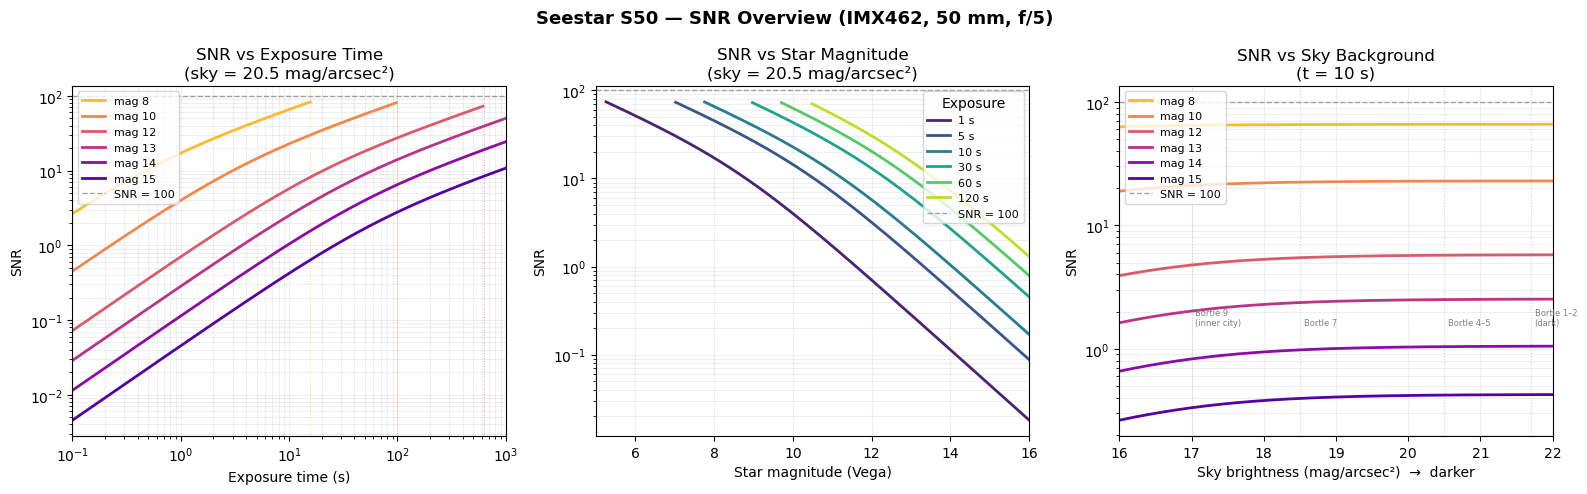

In [40]:
def star_flux(mag):
    """Star flux in e-/s."""
    return FLUX_ZP_E_S * 10**(-0.4 * mag)

def sky_flux_per_pix(sky_mag_arcsec2):
    """Sky background in e-/pix/s given surface brightness in mag/arcsec²."""
    return FLUX_ZP_E_S * 10**(-0.4 * sky_mag_arcsec2) * PIXEL_SCALE_ARCSEC**2

def snr_full(mag, exposure_s, sky_mag_arcsec2=20.5,
             read_noise=READ_NOISE_E, dark=DARK_CURRENT_E_S, n_pix=N_PIX):
    """Full aperture-photometry SNR including sky, dark, and read noise."""
    S = star_flux(mag) * exposure_s
    B = sky_flux_per_pix(sky_mag_arcsec2) * exposure_s
    D = dark * exposure_s
    noise_sq = S + n_pix * (B + D + read_noise**2)
    return S / np.sqrt(noise_sq)

# =============================================================================
# PLOT 1 — SNR vs Exposure Time  (for different star magnitudes)
# PLOT 2 — SNR vs Star Magnitude (for different exposure times)
# PLOT 3 — SNR vs Sky Background (for different star magnitudes)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Seestar S50 — SNR Overview (IMX462, 50 mm, f/5)", fontsize=13, fontweight="bold")

REF_SKY = 20.5   # mag/arcsec² (Bortle 4–5, typical suburban/rural border)
COLORS = plt.cm.plasma_r(np.linspace(0.15, 0.85, 6))

# ── Plot 1: SNR vs Exposure Time ──────────────────────────────────────────────
ax1 = axes[0]
t_arr = np.logspace(-1, 3, 400)   # 0.1 s … 1000 s
star_mags = [8, 10, 12, 13, 14, 15]

for i, mag in enumerate(star_mags):
    snr_arr = snr_full(mag, t_arr, sky_mag_arcsec2=REF_SKY)
    # Mask exposures that would saturate
    sat_t = calculate_max_exposure(mag)
    mask = t_arr <= sat_t
    ax1.loglog(t_arr[mask], snr_arr[mask], color=COLORS[i], lw=2, label=f"mag {mag}")
    if np.any(~mask):
        ax1.axvline(sat_t, color=COLORS[i], lw=0.7, ls=":", alpha=0.6)

ax1.axhline(100, color="gray", ls="--", lw=1, alpha=0.7, label="SNR = 100")
ax1.set_xlabel("Exposure time (s)")
ax1.set_ylabel("SNR")
ax1.set_title("SNR vs Exposure Time\n(sky = 20.5 mag/arcsec²)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, which="both", alpha=0.2)
ax1.set_xlim(0.1, 1000)

# ── Plot 2: SNR vs Star Magnitude ─────────────────────────────────────────────
ax2 = axes[1]
mag_arr = np.linspace(5, 16, 300)
exp_times = [1, 5, 10, 30, 60, 120]
colors2 = plt.cm.viridis(np.linspace(0.1, 0.9, len(exp_times)))

for i, exp in enumerate(exp_times):
    snr_arr = snr_full(mag_arr, exp, sky_mag_arcsec2=REF_SKY)
    # Mask stars that would saturate at this exposure
    sat_mag_limit = calculate_saturation_magnitude(exp)
    mask = mag_arr >= sat_mag_limit
    ax2.semilogy(mag_arr[mask], snr_arr[mask], color=colors2[i], lw=2, label=f"{exp} s")

ax2.axhline(100, color="gray", ls="--", lw=1, alpha=0.7, label="SNR = 100")
ax2.set_xlabel("Star magnitude (Vega)")
ax2.set_ylabel("SNR")
ax2.set_title("SNR vs Star Magnitude\n(sky = 20.5 mag/arcsec²)")
ax2.legend(fontsize=8, title="Exposure", loc="upper right")
ax2.grid(True, which="both", alpha=0.2)
ax2.set_xlim(5, 16)

# ── Plot 3: SNR vs Sky Background ─────────────────────────────────────────────
ax3 = axes[2]
# Sky brightness range: bright city (16) → excellent dark site (22)
sky_arr = np.linspace(16, 22, 300)
exp_fixed = 10  # s
star_mags3 = [8, 10, 12, 13, 14, 15]

# Bortle class labels for reference
bortle_labels = {17.0: "Bortle 9\n(inner city)", 18.5: "Bortle 7", 20.5: "Bortle 4–5", 21.7: "Bortle 1–2\n(dark)"}

for sky_b, label in bortle_labels.items():
    ax3.axvline(sky_b, color="lightgray", lw=0.8, ls=":")
    ax3.text(sky_b + 0.05, 1.5, label, fontsize=6, color="gray", va="bottom")

for i, mag in enumerate(star_mags3):
    snr_arr = np.array([snr_full(mag, exp_fixed, sky_mag_arcsec2=s) for s in sky_arr])
    ax3.semilogy(sky_arr, snr_arr, color=COLORS[i], lw=2, label=f"mag {mag}")

ax3.axhline(100, color="gray", ls="--", lw=1, alpha=0.7, label="SNR = 100")
ax3.set_xlabel("Sky brightness (mag/arcsec²)  →  darker")
ax3.set_ylabel("SNR")
ax3.set_title(f"SNR vs Sky Background\n(t = {exp_fixed} s)")
ax3.legend(fontsize=8, loc="upper left")
ax3.grid(True, which="both", alpha=0.2)
ax3.set_xlim(16, 22)

plt.tight_layout()
plt.show()


## Simulated Transit Light Curve ##

Generates a physically-motivated transit light curve ("temporal spectrum") for your target.
Uses a numerically computed, limb-darkened stellar disk and adds per-frame photon noise from the SNR model above.
Adjust the parameters at the top of the cell and re-run to explore different scenarios.

─── Transit geometry ────────────────────────────────
  Depth:              2.412%  (24118 ppm,  26.51 mmag)
  T₁₄ (total):        1.84 h
  T₂₃ (flat bottom):  1.03 h  (61.8 min)
  Ingress / egress:   24.3 min each
─── Photometry ──────────────────────────────────────
  SNR per frame:      52.4
  Noise per frame:    19.07 mmag
  Depth / frame σ:    1.4×
  Max safe exposure:  12 s  (no saturation)
  Frames in transit:  1324  →  22 bins of 5 min
  Binned σ (in-tran): 2.46 mmag per bin


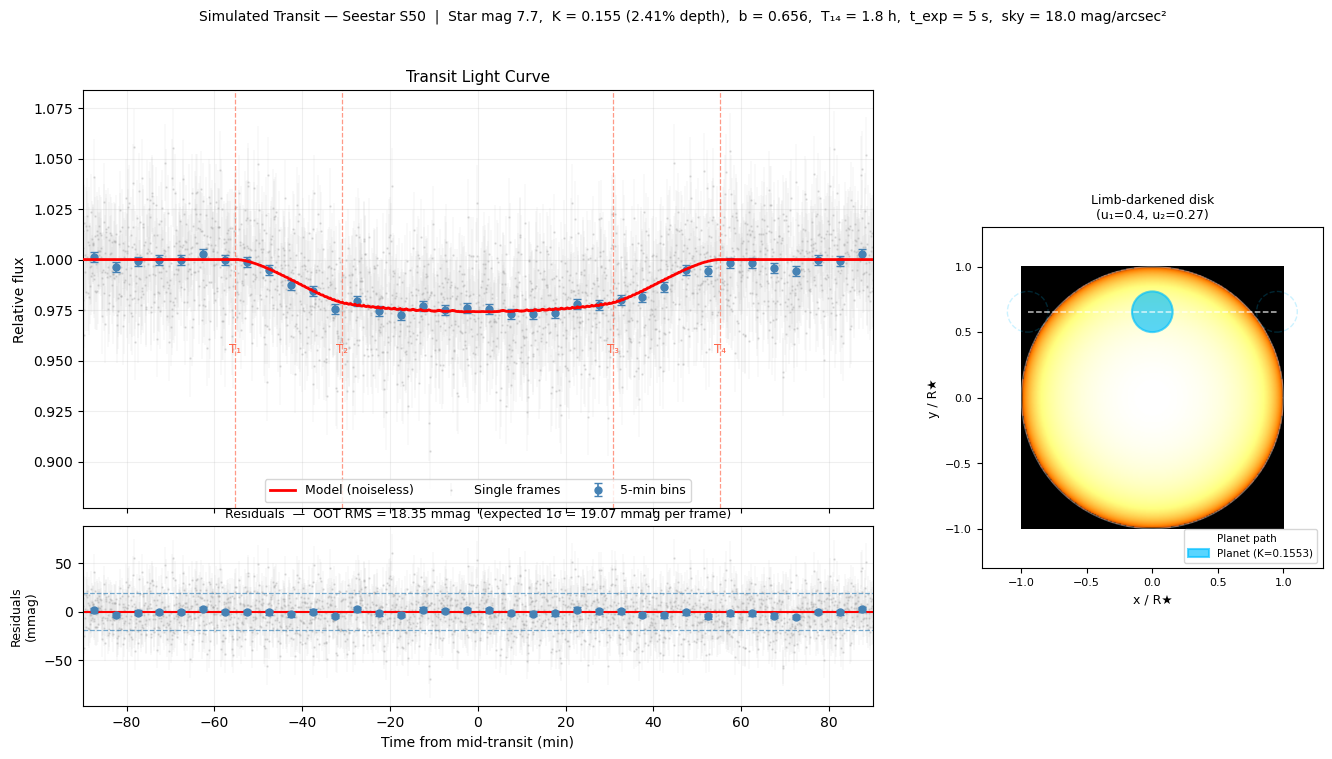

In [41]:
# =============================================================================
# DERIVED GEOMETRY
# =============================================================================
_depth  = K**2
_denom  = np.sqrt((1 + K)**2 - B_IMP**2)          # half-chord at first/fourth contact
T23_H   = T14_H * np.sqrt(max(0.0, (1 - K)**2 - B_IMP**2)) / _denom
ingress_m = (T14_H - T23_H) / 2 * 60              # ingress duration in minutes

snr_frame  = snr_full(STAR_MAG, EXPOSURE_S, sky_mag_arcsec2=SKY_MAG)
sigma_flux = 1.0 / snr_frame                       # fractional flux error per frame
depth_mmag = transit_depth_to_magnitude(_depth) * 1000

print("─── Transit geometry ────────────────────────────────")
print(f"  Depth:              {_depth*100:.3f}%  ({_depth*1e6:.0f} ppm,  {depth_mmag:.2f} mmag)")
print(f"  T₁₄ (total):        {T14_H:.2f} h")
print(f"  T₂₃ (flat bottom):  {T23_H:.2f} h  ({T23_H*60:.1f} min)")
print(f"  Ingress / egress:   {ingress_m:.1f} min each")
print("─── Photometry ──────────────────────────────────────")
print(f"  SNR per frame:      {snr_frame:.1f}")
print(f"  Noise per frame:    {sigma_flux*1e3:.2f} mmag")
print(f"  Depth / frame σ:    {depth_mmag / (sigma_flux*1e3):.1f}×")
print(f"  Max safe exposure:  {calculate_max_exposure(STAR_MAG):.0f} s  (no saturation)")
n_in = int(T14_H * 3600 / EXPOSURE_S)
n_bin_in = int(T14_H * 60 / BIN_MIN)
print(f"  Frames in transit:  {n_in}  →  {n_bin_in} bins of {BIN_MIN:.0f} min")
print(f"  Binned σ (in-tran): {sigma_flux/np.sqrt(n_in/n_bin_in)*1e3:.2f} mmag per bin")
if B_IMP >= 1 - K:
    print(f"  ⚠  Grazing transit (B={B_IMP} ≥ 1−K={1-K:.3f}); T₂₃ = 0.")

# =============================================================================
# LIMB-DARKENED STELLAR DISK  (computed once)
# =============================================================================
NG  = 200
xg  = np.linspace(-1.0, 1.0, NG)
Xg, Yg = np.meshgrid(xg, xg)
Rg  = np.sqrt(Xg**2 + Yg**2)
mu_g   = np.where(Rg <= 1.0, np.sqrt(np.clip(1.0 - Rg**2, 0, None)), 0.0)
I_disk = np.where(Rg <= 1.0, 1.0 - U1*(1 - mu_g) - U2*(1 - mu_g)**2, 0.0)
I_total = I_disk.sum()

# =============================================================================
# TIME ARRAY AND SEPARATION z(t)
# Circular orbit, linear approximation (valid when T₁₄ << orbital period)
# z² = B² + (2t/T₁₄ · √[(1+K)²−B²])²
# =============================================================================
N_frames = int(OBS_HOURS * 3600 / EXPOSURE_S) + 1
t_h  = np.linspace(-OBS_HOURS / 2, OBS_HOURS / 2, N_frames)   # hours
t_m  = t_h * 60.0                                               # minutes (plot axis)
z_arr = np.sqrt(B_IMP**2 + (2.0 * t_h / T14_H * _denom)**2)

# =============================================================================
# TRANSIT FLUX  (batched to keep memory < ~32 MB per batch)
# =============================================================================
BATCH = 50
flux_model = np.ones(N_frames)
for i0 in range(0, N_frames, BATCH):
    zb = z_arr[i0:i0 + BATCH]
    if np.all(zb >= 1.0 + K):          # entirely outside stellar disk → skip
        continue
    d2  = (Xg[:, :, None] - zb[None, None, :])**2 + Yg[:, :, None]**2
    blk = np.sum(I_disk[:, :, None] * (d2 <= K**2), axis=(0, 1))
    flux_model[i0:i0 + BATCH] = 1.0 - blk / I_total

# =============================================================================
# ADD PHOTON NOISE
# =============================================================================
rng      = np.random.default_rng(SEED)
flux_obs = flux_model + rng.normal(0.0, sigma_flux, N_frames)

# =============================================================================
# BIN THE LIGHT CURVE
# =============================================================================
bin_edges   = np.arange(t_m[0], t_m[-1] + BIN_MIN, BIN_MIN)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_flux, bin_err = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    idx = (t_m >= lo) & (t_m < hi)
    n   = idx.sum()
    if n > 0:
        bin_flux.append(flux_obs[idx].mean())
        bin_err.append(sigma_flux / np.sqrt(n))
    else:
        bin_flux.append(np.nan)
        bin_err.append(np.nan)
bin_flux = np.array(bin_flux)
bin_err  = np.array(bin_err)
bin_model = np.interp(bin_centers / 60, t_h, flux_model)

# =============================================================================
# FIGURE
# =============================================================================
fig = plt.figure(figsize=(16, 8))
fig.suptitle(
    f"Simulated Transit — Seestar S50  |  "
    f"Star mag {STAR_MAG},  K = {K:.3f} ({_depth*100:.2f}% depth),  "
    f"b = {B_IMP},  T₁₄ = {T14_H:.1f} h,  "
    f"t_exp = {EXPOSURE_S:.0f} s,  sky = {SKY_MAG} mag/arcsec²",
    fontsize=10)

gs = gridspec.GridSpec(2, 3, height_ratios=[3.5, 1.5], hspace=0.06, wspace=0.32)
ax_lc   = fig.add_subplot(gs[0, 0:2])
ax_res  = fig.add_subplot(gs[1, 0:2], sharex=ax_lc)
ax_disk = fig.add_subplot(gs[:, 2], aspect="equal")
plt.setp(ax_lc.get_xticklabels(), visible=False)

# ── Light curve ────────────────────────────────────────────────────────────
ax_lc.errorbar(t_m, flux_obs, yerr=sigma_flux, fmt=".", ms=1.5,
               color="0.65", elinewidth=0.3, alpha=0.30, label="Single frames", zorder=1)
ax_lc.errorbar(bin_centers, bin_flux, yerr=bin_err, fmt="o", ms=5,
               color="steelblue", capsize=3, elinewidth=1.2,
               label=f"{BIN_MIN:.0f}-min bins", zorder=3)
ax_lc.plot(t_m, flux_model, "r-", lw=2.0, zorder=4, label="Model (noiseless)")

# Contact time markers
y_label = 1 - _depth * 1.7
for tc, lab in [(-T14_H/2*60, "T₁"), (-T23_H/2*60, "T₂"),
                ( T23_H/2*60, "T₃"), ( T14_H/2*60,  "T₄")]:
    ax_lc.axvline(tc, color="tomato", lw=0.9, ls="--", alpha=0.65)
    ax_lc.text(tc, y_label, lab, ha="center", va="top", fontsize=8.5, color="tomato")

ax_lc.set_ylabel("Relative flux", fontsize=10)
ax_lc.set_title("Transit Light Curve", fontsize=11)
ax_lc.legend(fontsize=9, loc="lower center", ncol=3)
ax_lc.grid(alpha=0.2)
ax_lc.set_xlim(t_m[0], t_m[-1])

# ── Residuals ──────────────────────────────────────────────────────────────
resid_raw = (flux_obs  - flux_model)   * 1e3   # mmag
resid_bin = (bin_flux  - bin_model)    * 1e3
ax_res.errorbar(t_m, resid_raw, yerr=sigma_flux*1e3, fmt=".", ms=1.5,
                color="0.65", elinewidth=0.3, alpha=0.30, zorder=1)
ax_res.errorbar(bin_centers, resid_bin, yerr=bin_err*1e3, fmt="o", ms=5,
                color="steelblue", capsize=3, elinewidth=1.2, zorder=3)
ax_res.axhline(0, color="r", lw=1.5)
for sign in (+1, -1):
    ax_res.axhline(sign * sigma_flux * 1e3, color="C0", ls="--", lw=0.9, alpha=0.6)

oot_mask = np.abs(t_h) > T14_H / 2
rms_oot  = np.std(resid_raw[oot_mask]) if oot_mask.any() else np.nan
ax_res.set_xlabel("Time from mid-transit (min)", fontsize=10)
ax_res.set_ylabel("Residuals\n(mmag)", fontsize=9)
ax_res.set_title(
    f"Residuals  —  OOT RMS = {rms_oot:.2f} mmag  "
    f"(expected 1σ = {sigma_flux*1e3:.2f} mmag per frame)", fontsize=9)
ax_res.grid(alpha=0.2)

# ── Stellar disk ────────────────────────────────────────────────────────────
ax_disk.imshow(I_disk, extent=[-1, 1, -1, 1], origin="lower",
               cmap="afmhot", vmin=0, interpolation="bilinear")
# Stellar limb
theta = np.linspace(0, 2*np.pi, 400)
ax_disk.plot(np.cos(theta), np.sin(theta), "w-", lw=0.9, alpha=0.35)
# Planet path
x_tr = np.linspace(-_denom, _denom, 300)
ax_disk.plot(x_tr, np.full_like(x_tr, B_IMP), "w--", lw=1.1, alpha=0.75, label="Planet path")
# Planet at mid-transit (x=0)
ax_disk.add_patch(plt.Circle((0, B_IMP), K, color="deepskyblue",
                              alpha=0.65, lw=1.5, label=f"Planet (K={K})"))
# First / fourth contact positions
for x_c in [-_denom, _denom]:
    ax_disk.add_patch(plt.Circle((x_c, B_IMP), K, color="deepskyblue",
                                  alpha=0.20, lw=1.0, ls="--", fill=False))

ax_disk.set_xlim(-1.3, 1.3)
ax_disk.set_ylim(-1.3, 1.3)
ax_disk.set_xlabel("x / R★", fontsize=9)
ax_disk.set_ylabel("y / R★", fontsize=9)
ax_disk.set_title(f"Limb-darkened disk\n(u₁={U1}, u₂={U2})", fontsize=9)
ax_disk.legend(fontsize=7.5, loc="lower right")
ax_disk.tick_params(labelsize=8)

plt.show()


## Tonight's Best Observable Transits ##

Queries the **NASA Exoplanet Archive** (TAP/ADQL, no API key required) for all
well-characterised transiting planets whose transit overlaps tonight's dark
window at your location.  Each candidate is filtered by:

- **Altitude** — star must stay above `MIN_ALT` throughout the transit
- **Magnitude** — not too bright (saturation) and not too faint (SNR)
- **Transit depth** — at least `MIN_DEPTH` percent

Candidates are scored by `depth × SNR/5min × coverage × sin(altitude)` and the
top `N_TOP` are displayed as simulated light curves using the same limb-darkened
model and noise model from the cells above.

**Requires:** `astropy` — install once with `pip install astropy`


Site        : Munich, Germany  (+48.135°, +11.582°)
Dark window : 2026-05-27 20:36  –  2026-05-28 01:48  UTC  (5.2 h)

Querying NASA Exoplanet Archive … 254 planets retrieved.

3 observable transits tonight  →  showing top 3

  Planet                    V   Depth    Dur    Alt    Cov  SNR/5min  Mid-transit (UTC)
  ──────────────────────────────────────────────────────────────────────────────
  KELT-24 b               8.3   0.76%   4.3h    36°    70%       306  2026-05-28 00:55
  TOI-1855 b             11.2   0.71%   1.2h    39°   100%        67  2026-05-27 23:20
  XO-7 b                 10.5   0.91%   2.8h    50°    21%       101  2026-05-27 19:47


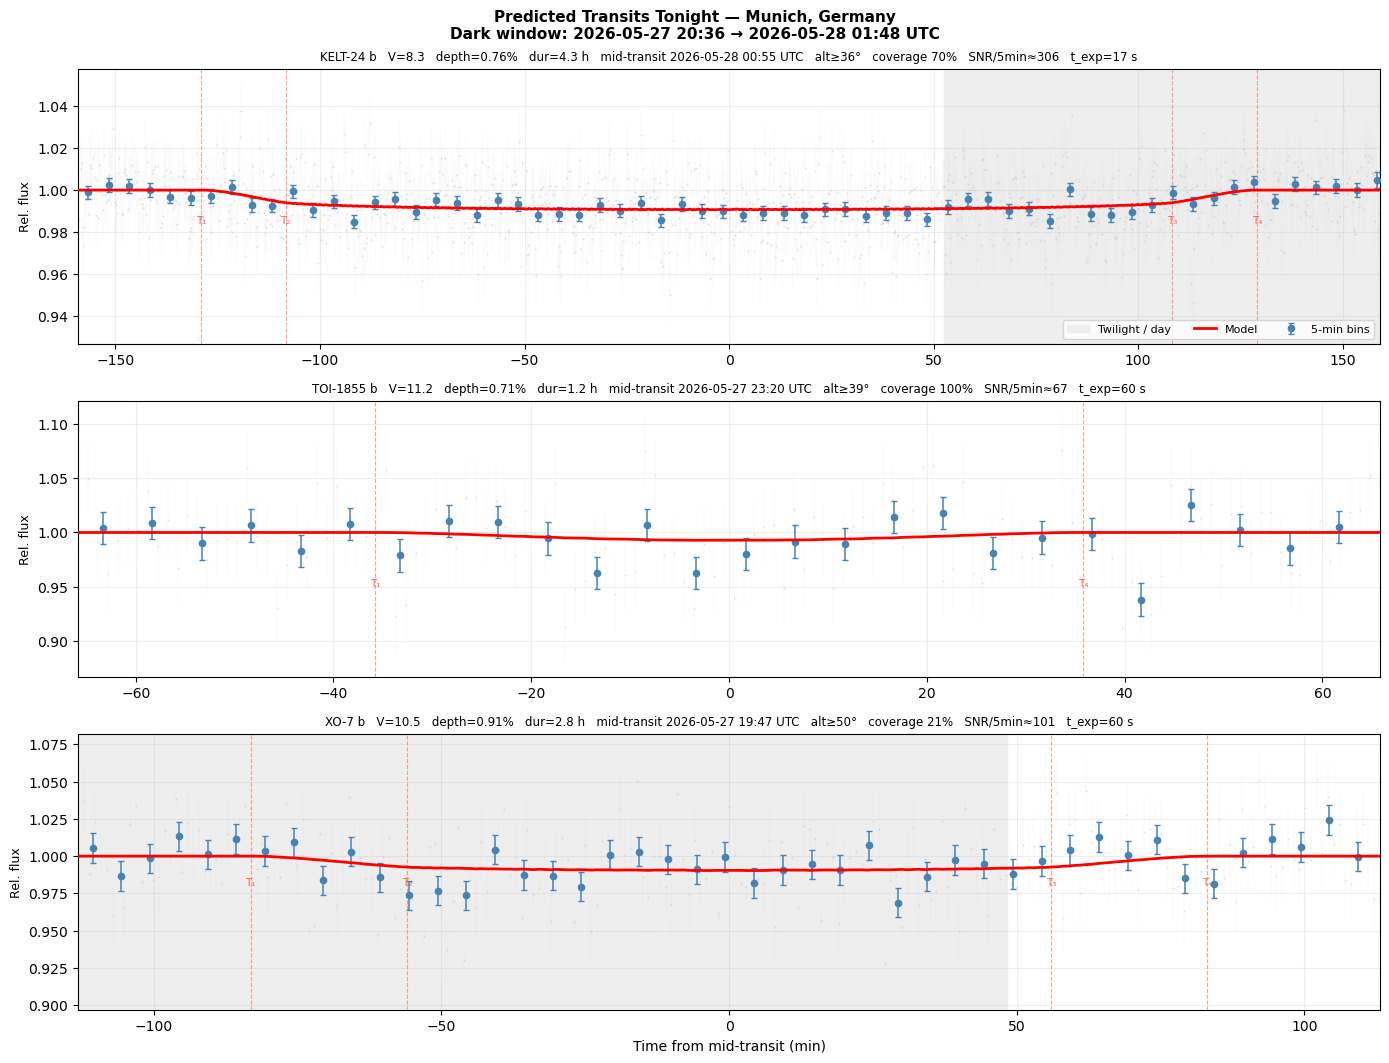

In [42]:
# =============================================================================
# BUILD OBSERVER & FIND TONIGHT'S DARK WINDOW
# =============================================================================
obs_loc = EarthLocation(lat=LAT*u.deg, lon=LON*u.deg, height=ELEV_M*u.m)
now     = Time.now()

# Vectorised sun-altitude scan over the next 36 h
t_arr   = now + np.arange(0, 36.0, 0.1) * u.hour
af_scan = AltAz(obstime=t_arr, location=obs_loc)
sun_alt = get_sun(t_arr).transform_to(af_scan).alt.deg   # vectorised
dark    = sun_alt < -12.0   # nautical twilight boundary

if dark.sum() > 2:
    dark_start = t_arr[np.argmax(dark)]
    dark_end   = t_arr[len(dark) - 1 - np.argmax(dark[::-1])]
else:
    dark_start, dark_end = now, now + 8*u.hour
    print("⚠  No dark window in next 36 h — using 8-h placeholder.")

ds_jd = dark_start.tdb.jd   # work in JD TDB throughout
de_jd = dark_end.tdb.jd

print(f"Site        : {SITE_NAME}  ({LAT:+.3f}°, {LON:+.3f}°)")
print(f"Dark window : {dark_start.utc.iso[:16]}  –  {dark_end.utc.iso[:16]}  UTC  "
      f"({(de_jd - ds_jd)*24:.1f} h)")

# =============================================================================
# QUERY NASA EXOPLANET ARCHIVE (TAP / ADQL — no authentication required)
# pl_trandep is in % (e.g. 1.0 = 1%); pl_trandur is in hours
# =============================================================================
ADQL = (
    "SELECT pl_name,hostname,ra,dec,sy_vmag,"
    "pl_orbper,pl_tranmid,pl_trandur,pl_trandep,pl_ratror,pl_imppar "
    "FROM pscomppars "
    "WHERE tran_flag=1 "
    "AND pl_orbper IS NOT NULL AND pl_tranmid IS NOT NULL "
    "AND pl_trandur IS NOT NULL AND pl_ratror IS NOT NULL "
    "AND pl_trandep IS NOT NULL AND sy_vmag IS NOT NULL "
    f"AND sy_vmag>={BRIGHT_LIMIT} AND sy_vmag<={FAINT_LIMIT} "
    f"AND pl_trandep>={MIN_DEPTH}"   # pl_trandep is in % (e.g. 1.0 = 1%)
)

print("\nQuerying NASA Exoplanet Archive … ", end="", flush=True)
try:
    resp = requests.get(
        "https://exoplanetarchive.ipac.caltech.edu/TAP/sync",
        params={"query": ADQL, "format": "csv"},
        timeout=45
    )
    resp.raise_for_status()
    planets = list(csv.DictReader(io.StringIO(resp.text)))
    print(f"{len(planets)} planets retrieved.")
except Exception as err:
    print(f"\nFailed: {err}")
    raise

# =============================================================================
# HELPERS
# =============================================================================
def sfloat(v, default=None):
    """Safe string-to-float; returns default for empty / NaN values."""
    try:
        x = float(v)
        return x if np.isfinite(x) else default
    except (TypeError, ValueError):
        return default

def transits_tonight(T0_jd, per_d, dur_h, win0_jd, win1_jd):
    """JD mid-times of transits whose ±½duration overlaps [win0, win1]."""
    hd = dur_h / 48.0
    n0 = int(np.floor((win0_jd - hd - T0_jd) / per_d))
    n1 = int(np.ceil( (win1_jd + hd - T0_jd) / per_d))
    return [T0_jd + n*per_d for n in range(n0, n1+1)
            if  T0_jd + n*per_d + hd >= win0_jd
            and T0_jd + n*per_d - hd <= win1_jd]

def min_alt_deg(coord, t0_jd, t1_jd, n=10):
    """Minimum altitude (°) of coord between two JD times."""
    tt = Time(np.linspace(t0_jd, t1_jd, n), format="jd", scale="tdb")
    return float(coord.transform_to(AltAz(obstime=tt, location=obs_loc)).alt.deg.min())

# =============================================================================
# FIND, FILTER & RANK OBSERVABLE TRANSITS
# =============================================================================
candidates = []
for p in planets:
    T0   = sfloat(p["pl_tranmid"]);  per  = sfloat(p["pl_orbper"])
    dur  = sfloat(p["pl_trandur"]);  dep  = sfloat(p["pl_trandep"])   # % (e.g. 1.0 = 1%)
    vmag = sfloat(p["sy_vmag"]);     ra   = sfloat(p["ra"])
    dec  = sfloat(p["dec"]);         K    = sfloat(p["pl_ratror"])
    bimp = sfloat(p["pl_imppar"], 0.0)

    if None in (T0, per, dur, dep, vmag, ra, dec, K) or K <= 0:
        continue
    bimp = np.clip(abs(bimp), 0.0, 1.0 + K - 1e-4)

    coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")

    for mid_jd in transits_tonight(T0, per, dur, ds_jd, de_jd):
        t1j = mid_jd - dur / 48.0
        t4j = mid_jd + dur / 48.0
        # Clip to observable window for altitude check
        ot0 = max(t1j, ds_jd)
        ot1 = min(t4j, de_jd)
        if ot1 <= ot0:
            continue
        alt = min_alt_deg(coord, ot0, ot1)
        if alt < MIN_ALT:
            continue

        frac     = (ot1 - ot0) / (t4j - t1j)
        exp      = max(1.0, min(calculate_max_exposure(vmag) * 0.8, 60.0))
        snr5     = snr_full(vmag, exp, sky_mag_arcsec2=SKY_MAG_OBS) * np.sqrt(300.0 / exp)
        dep_pct  = dep              # already in %
        score    = dep_pct * min(snr5, 1000) / 100 * frac * np.sin(np.radians(alt))

        candidates.append(dict(
            name=p["pl_name"], host=p["hostname"], vmag=vmag, coord=coord,
            tmid_jd=mid_jd, t1_jd=t1j, t4_jd=t4j,
            dur=dur, dep_pct=dep_pct, K=K, bimp=bimp,
            alt=alt, frac=frac, exp=exp, snr5=snr5, score=score
        ))

# De-duplicate: keep best-scoring transit per planet
seen = {}
for c in candidates:
    if c["name"] not in seen or c["score"] > seen[c["name"]]["score"]:
        seen[c["name"]] = c
top = sorted(seen.values(), key=lambda x: -x["score"])[:N_TOP]

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{len(seen)} observable transits tonight  →  showing top {len(top)}\n")
print(f"  {'Planet':<22}{'V':>5}  {'Depth':>6}  {'Dur':>5}  {'Alt':>5}  "
      f"{'Cov':>5}  {'SNR/5min':>8}  Mid-transit (UTC)")
print("  " + "─" * 78)
for c in top:
    mid = Time(c["tmid_jd"], format="jd", scale="tdb").utc.iso[:16]
    print(f"  {c['name']:<22}{c['vmag']:5.1f}  {c['dep_pct']:5.2f}%  "
          f"{c['dur']:4.1f}h  {c['alt']:4.0f}°  {c['frac']*100:4.0f}%  "
          f"{c['snr5']:8.0f}  {mid}")

# =============================================================================
# SIMULATE & PLOT LIGHT CURVES
# =============================================================================
if not top:
    print("\nNo transits found. Try relaxing MIN_ALT, FAINT_LIMIT, or MIN_DEPTH.")
else:
    # Shared limb-darkened stellar disk (quadratic, solar G-type V-band)
    NG = 160
    xg = np.linspace(-1.0, 1.0, NG)
    Xg, Yg = np.meshgrid(xg, xg)
    Rg  = np.sqrt(Xg**2 + Yg**2)
    mu  = np.where(Rg <= 1, np.sqrt(np.clip(1 - Rg**2, 0, None)), 0.0)
    u1d, u2d = 0.40, 0.27   # solar coefficients, V-band
    I_d  = np.where(Rg <= 1, 1 - u1d*(1 - mu) - u2d*(1 - mu)**2, 0.0)
    I_dt = I_d.sum()

    rng  = np.random.default_rng(SEED)
    n_tp = len(top)
    fig, axes = plt.subplots(n_tp, 1, figsize=(14, 3.6 * n_tp), squeeze=False)
    axes = axes.ravel()
    fig.suptitle(
        f"Predicted Transits Tonight — {SITE_NAME}\n"
        f"Dark window: {dark_start.utc.iso[:16]} → {dark_end.utc.iso[:16]} UTC",
        fontsize=11, fontweight="bold"
    )

    for ax, c in zip(axes, top):
        K    = c["K"];    bimp = c["bimp"]
        dur  = c["dur"];  vmag = c["vmag"];  exp = c["exp"]

        _dn    = np.sqrt(max(1e-9, (1 + K)**2 - bimp**2))   # half-chord T1/T4
        _dn23  = max(0.0, (1 - K)**2 - bimp**2)             # half-chord² T2/T3
        T23h   = dur * np.sqrt(_dn23) / _dn                 # flat-bottom duration (h)

        # Time array: transit + 30-min padding on each side
        obs_h  = dur + 1.0
        N_f    = int(obs_h * 3600 / exp) + 1
        t_h    = np.linspace(-obs_h / 2, obs_h / 2, N_f)
        t_m    = t_h * 60

        # ── Transit model (batched, limb-darkened) ────────────────────────────
        z_arr  = np.sqrt(bimp**2 + (2.0 * t_h / dur * _dn)**2)
        flux_m = np.ones(N_f)
        BATCH  = 50
        for i0 in range(0, N_f, BATCH):
            zb = z_arr[i0:i0 + BATCH]
            if np.all(zb >= 1.0 + K):
                continue
            d2  = (Xg[:, :, None] - zb[None, None, :])**2 + Yg[:, :, None]**2
            blk = np.sum(I_d[:, :, None] * (d2 <= K**2), axis=(0, 1))
            flux_m[i0:i0 + BATCH] = 1.0 - blk / I_dt

        # ── Noise ─────────────────────────────────────────────────────────────
        sigma  = 1.0 / snr_full(vmag, exp, sky_mag_arcsec2=SKY_MAG_OBS)
        flux_o = flux_m + rng.normal(0.0, sigma, N_f)

        # ── Binned light curve ─────────────────────────────────────────────────
        b_edges = np.arange(t_m[0], t_m[-1] + BIN_MIN, BIN_MIN)
        b_ctrs  = (b_edges[:-1] + b_edges[1:]) / 2
        bfl, ber = [], []
        for lo, hi in zip(b_edges[:-1], b_edges[1:]):
            idx = (t_m >= lo) & (t_m < hi); nb = idx.sum()
            bfl.append(flux_o[idx].mean() if nb else np.nan)
            ber.append(sigma / np.sqrt(nb) if nb else np.nan)
        bfl = np.array(bfl);  ber = np.array(ber)

        # ── Grey out unobservable (daytime / twilight) regions ────────────────
        mid_jd  = c["tmid_jd"]
        ds_m    = (ds_jd - mid_jd) * 1440   # dark-start offset in minutes
        de_m    = (de_jd - mid_jd) * 1440
        first   = True
        for lo_m, hi_m in [(t_m[0], min(t_m[-1], ds_m)),
                            (max(t_m[0], de_m), t_m[-1])]:
            if hi_m > lo_m:
                lbl = "Twilight / day" if first else "_"
                ax.axvspan(lo_m, hi_m, color="#eeeeee", zorder=0, label=lbl)
                first = False

        # ── Plot ──────────────────────────────────────────────────────────────
        ax.errorbar(t_m, flux_o, yerr=sigma, fmt=".", ms=1.5,
                    color="0.70", elinewidth=0.2, alpha=0.22, zorder=1)
        ax.errorbar(b_ctrs, bfl, yerr=ber, fmt="o", ms=4.5, color="steelblue",
                    capsize=2.5, elinewidth=1.1, zorder=3,
                    label=f"{BIN_MIN:.0f}-min bins")
        ax.plot(t_m, flux_m, "r-", lw=2.0, zorder=4, label="Model")

        # Contact markers
        for tc, lab in [(-dur/2*60, "T₁"), (dur/2*60, "T₄")]:
            ax.axvline(tc, color="tomato", lw=0.8, ls="--", alpha=0.6)
            ax.text(tc, 1 - K**2 * 1.6, lab, ha="center", va="top",
                    fontsize=7.5, color="tomato")
        if T23h > 0:
            for tc, lab in [(-T23h/2*60, "T₂"), (T23h/2*60, "T₃")]:
                ax.axvline(tc, color="tomato", lw=0.8, ls="--", alpha=0.6)
                ax.text(tc, 1 - K**2 * 1.6, lab, ha="center", va="top",
                        fontsize=7.5, color="tomato")

        mid_str = Time(mid_jd, format="jd", scale="tdb").utc.iso[:16]
        ax.set_title(
            f"{c['name']}   V={vmag:.1f}   depth={c['dep_pct']:.2f}%   "
            f"dur={dur:.1f} h   mid-transit {mid_str} UTC   "
            f"alt≥{c['alt']:.0f}°   coverage {c['frac']*100:.0f}%   "
            f"SNR/5min≈{c['snr5']:.0f}   t_exp={exp:.0f} s",
            fontsize=8.5
        )
        ax.set_ylabel("Rel. flux", fontsize=9)
        ax.set_xlim(t_m[0], t_m[-1])
        ax.grid(alpha=0.2)
        if ax is axes[0]:
            ax.legend(fontsize=8, loc="lower right", ncol=3)

    axes[-1].set_xlabel("Time from mid-transit (min)", fontsize=10)
    plt.tight_layout()
    plt.show()
